# Assignment 2: Feature Engineering & Versioning

## Wo befinden wir uns im MLOps-Projekt?

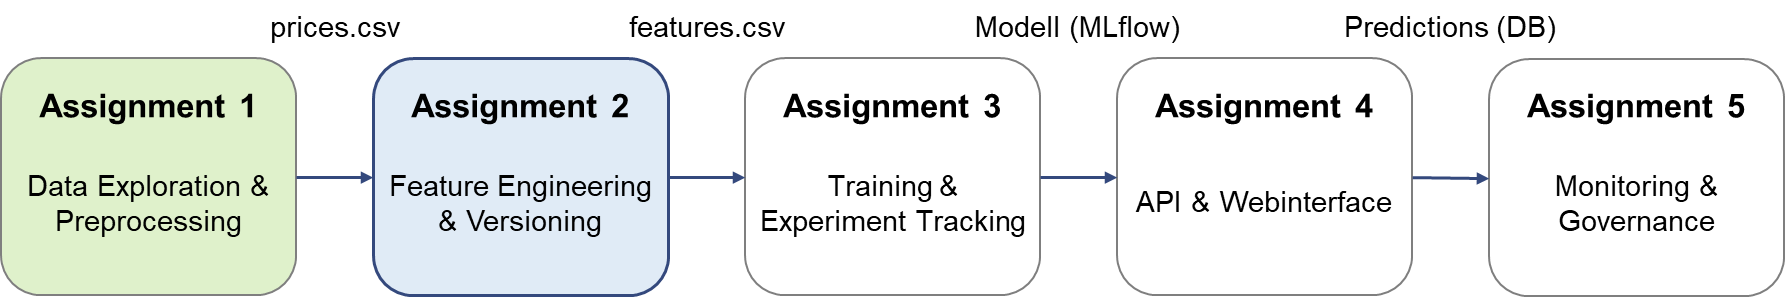

## Was passiert in diesem Notebook?

Sie wandeln die stündlichen Rohdaten (`prices.csv`) in einen **ML-ready Feature-Vektor** um. Das Modell lernt nicht aus "rohen" Preisen, sondern aus **zeitlichen Mustern** – wie stark schwankt der Kraftstoffpreis im Vergleich zur letzten Stunde, zum Vortag, zur letzten Woche?

Ihre Aufgabe:
1. **Daten laden** (`load_data`): `prices.csv` einlesen und Zeitreihe aufbereiten
2. **Features erstellen** (`create_features`): Pflicht-Zeitmerkmale + eigene Features berechnen
3. **Pipeline orchestrieren** (`run_preprocessing`): `features.csv` speichern

**Voraussetzung:** A1 abgeschlossen (`data/raw/prices.csv` vorhanden)  
**Ausgabe:** `data/processed/features.csv`  

---

**Pflicht-Features (müssen vorhanden sein):**

Als Mindestanforderung müssen Sie vier Zeitmerkmale berechnen: Stunde des Tages (`hour`),
Wochentag (`day_of_week`), Monat (`month`) und einen Wochenend-Indikator (`is_weekend`).
Die Zielvariable `{FUEL_TYPE}_price_next_hour` (Preis der nächsten Stunde) ist ebenfalls Pflicht.
Darüber hinaus entscheiden Sie selbst, welche weiteren Features sinnvoll sind –
typisch sind historische Preise (Lag-Features), gleitende Mittelwerte und Preisänderungen.

> ⚠️ **KRITISCH:** Die Spaltenreihenfolge Ihrer `features.csv` bestimmt die Feature-Reihenfolge
> im Modell. A3 und A4 (`predict.py`) müssen dieselbe Reihenfolge verwenden!

**Funktionen zu implementieren:**
| Funktion | Beschreibung |
|---|---|
| `load_data()` | prices.csv laden + Zeitindex setzen |
| `create_features()` | Pflicht-Features + eigene Features + Zielvariable berechnen |
| `run_preprocessing()` | Orchestrierung → features.csv speichern |

## Bewertungskriterien (17 Punkte)

| Kriterium | Punkte |
|---|---|
| Standard-Features (Lag, Moving Avg, Target) – korrekt, kein Data-Leakage | 4 |
| Eigene kreative Features (mind. 3) mit dokumentierter Begründung | 6 |
| DVC-Setup & Daten-Versionierung (`dvc.yaml`, getrackte Dateien, git integration) | 4 |
| Reproduzierbarkeit & Dokumentation (`dvc repro` läuft end-to-end) | 3 |
| **Gesamt** | **17** |

**Abgabe: 23.04.2026 um 23:59 Uhr**

In [ ]:
import os, sys

_cwd = os.getcwd()
PROJECT_ROOT = _cwd if os.path.exists(os.path.join(_cwd, "config.py")) \
               else os.path.abspath(os.path.join(_cwd, ".."))
sys.path.insert(0, PROJECT_ROOT)

import pandas as pd
import numpy as np

from config import GROUP_ID, DEFAULT_PARAMS, FUEL_TYPE

params   = DEFAULT_PARAMS
raw_path = os.path.join(PROJECT_ROOT, params["paths"]["raw_prices"])

print(f"Gruppe      : {GROUP_ID}")
print(f"Kraftstoff  : {FUEL_TYPE}")
print(f"Eingabe     : {raw_path}")

---
## TODO (1/3): `load_data()`

### Aufgabe

`load_data()` liest die von A1 erzeugte `prices.csv` ein und bereitet den DataFrame für die
Feature-Berechnung vor. Der stündliche Zeitindex muss vollständig sein – Lücken würden zu
falschen Lag-Werten führen.

### Hintergrund

Die Lag-Berechnungen (z.B. `lag_1h`) verschieben den DataFrame um eine oder mehrere Zeilen.
Das funktioniert nur korrekt, wenn tatsächlich eine Zeile pro Stunde vorhanden ist.
Falls in der CSV Stunden fehlen, müssen diese aufgefüllt werden.

### Hinweise
- `pd.read_csv(raw_path)` einlesen und `datetime`-Spalte als UTC-Timestamp parsen
- Aufsteigend sortieren mit `sort_values("datetime")`
- Rückgabe: DataFrame mit Spalten `datetime` (UTC-aware) und dem Kraftstoffpreis der gewählten Kraftstoffsorte (EUR/L)

**Dokumentation:**
- [pandas.read_csv](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html) – CSV-Datei in DataFrame laden
- [pandas.to_datetime](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) – String → datetime (mit `utc=True`)
- [DataFrame.sort_values](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html) – Zeilen nach Spalte sortieren

In [ ]:
def load_data(raw_path: str) -> pd.DataFrame:
    """
    Lädt stündliche Kraftstoffpreise aus der CSV-Datei, die A1 erzeugt hat.

    Args:
        raw_path: Pfad zu data/raw/prices.csv

    Returns:
        DataFrame mit Spalten:
            datetime              (datetime, UTC-aware) – stündliche Zeitstempel
            {FUEL_TYPE}_price     (float)               – Kraftstoffpreis in EUR/L

    Interface ← A1:
        Erwartet prices.csv mit genau diesen Spalten (Ausgabe von A1).
    Interface → create_features():
        Gibt diesen DataFrame weiter an create_features().
    """
    # Schritt 1: CSV laden

    # Schritt 2: datetime-Spalte als UTC-Timestamp parsen

    # Schritt 3: Aufsteigend sortieren und Index zurücksetzen

    raise NotImplementedError("TODO (1/3): load_data implementieren")

# Test
raw_df = load_data(raw_path)
print(f"Geladen: {len(raw_df):,} Zeilen")
print(f"Zeitraum: {raw_df['datetime'].min()} bis {raw_df['datetime'].max()}")
raw_df.head(3)

---
## TODO (2/3): `create_features()`

### Aufgabe

`create_features()` erstellt den ML-Feature-Vektor aus den stündlichen Kraftstoffpreisen der gewählten Kraftstoffsorte.
Als Mindestanforderung müssen Sie vier Zeitmerkmale berechnen: Stunde des Tages (`hour`),
Wochentag (`day_of_week`), Monat (`month`) und einen Wochenend-Indikator (`is_weekend`).
Darüber hinaus entscheiden Sie selbst, welche weiteren Features sinnvoll sind –
typisch sind historische Preise (Lag-Features), gleitende Mittelwerte und Preisänderungen.

### Hintergrund

Rohe Preise sind für ein ML-Modell wenig aussagekräftig. Entscheidend sind relative
Veränderungen und zeitliche Muster.

Die **Zielvariable** `{FUEL_TYPE}_price_next_hour` ist der Kraftstoffpreis in der nächsten Stunde –
das ist es, was das Modell vorhersagen soll.

### Hinweise
- Zeitliche Features: `df["datetime"].dt.hour`, `.dt.dayofweek`, `.dt.month`
- Lag-Features: `df[f"{FUEL_TYPE}_price"].shift(h)` mit h = Anzahl Stunden
- Zielvariable: `df[f"{FUEL_TYPE}_price"].shift(-1)` (nächste Stunde)
- `df.dropna()` am Ende entfernt Zeilen mit unvollständigen Lag-Werten
- **KEIN shuffle!** Die zeitliche Reihenfolge ist für Lag-Berechnungen und den temporalen Split in A3 zwingend erforderlich

**Dokumentation:**
- [Series.dt Accessor](https://pandas.pydata.org/docs/reference/api/pandas.Series.dt.html) – `.dt.hour`, `.dt.dayofweek`, `.dt.month` aus datetime-Spalte
- [Series.shift](https://pandas.pydata.org/docs/reference/api/pandas.Series.shift.html) – Lag-Features: positive Werte = Vergangenheit, negativ = Zukunft
- [Series.rolling](https://pandas.pydata.org/docs/reference/api/pandas.Series.rolling.html) – Gleitender Mittelwert mit `.rolling(n).mean()`
- [Series.diff](https://pandas.pydata.org/docs/reference/api/pandas.Series.diff.html) – Differenz zum Wert vor n Zeitschritten

### Bewertungskriterien

**Pflicht:**
- `hour`, `day_of_week`, `month`, `is_weekend` vorhanden und korrekt berechnet
- `{FUEL_TYPE}_price_next_hour` als Zielvariable ohne Look-ahead (`shift(-1)`)
- Keine NaN-Werte im Ergebnis (`dropna()` angewendet)
- Zeitliche Reihenfolge erhalten (kein shuffle)

**Optional (+):**
- Mindestens ein Lag-Feature
- Moving Average oder Differenz-Feature vorhanden
- Kurze Markdown-Zelle oder Kommentar: welches Feature hat welchen Effekt und warum?

In [ ]:
def create_features(df: pd.DataFrame, params: dict) -> pd.DataFrame:
    """
    Erstellt alle ML-Features aus den stündlichen Kraftstoffpreisen der gewählten Kraftstoffsorte.

    Args:
        df:     DataFrame aus load_data() mit Spalten datetime, {FUEL_TYPE}_price
        params: DEFAULT_PARAMS aus config.py
                  params["features"]["target_column"] = f"{FUEL_TYPE}_price_next_hour"

    Returns:
        DataFrame mit Pflicht-Spalten + eigenen Features (mind. 7 Spalten):
            Pflicht: datetime, {FUEL_TYPE}_price, hour, day_of_week, month,
                     is_weekend, {FUEL_TYPE}_price_next_hour
            Optional: beliebige weitere Features nach eigenem Ermessen
                      (z.B. historische Lags, Moving Average, Differenzen)

        ⚠ KEIN shuffle! Reihenfolge beibehalten (Basis für Lag-Berechnungen).

    Interface → A3/A5:
        A3 (Training) und A5 (predict.py) verwenden alle Spalten außer
        datetime, {FUEL_TYPE}_price, {FUEL_TYPE}_price_next_hour als Feature-Matrix.
        Die Spaltenreihenfolge deiner features.csv bestimmt die
        Feature-Reihenfolge im Modell – predict.py muss dieselbe
        Reihenfolge reproduzieren.
    """
    df = df.copy()

    # Hinweis: Die Zielspalte heißt f"{FUEL_TYPE}_price_next_hour" (aus config.py)

    # Schritt 1: Zeitliche Features ableiten (Pflicht!)

    # Schritt 2: Weitere Features nach eigenem Ermessen (Lags, Moving Average, Differenzen etc.)

    # Schritt 3: Zielvariable (nächste Stunde, kein Look-ahead!)

    # Schritt 4: NaN-Zeilen entfernen, Index zurücksetzen (KEIN shuffle!)

    raise NotImplementedError("TODO (2/3): create_features implementieren")

# Test
features_df = create_features(raw_df.copy(), params)
target_col  = params["features"]["target_column"]
feature_cols = [c for c in features_df.columns if c not in ["datetime", f"{FUEL_TYPE}_price", target_col]]
print(f"Feature-Matrix : {features_df.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Zielvariable   : {target_col}")
features_df.head(3)

---
## Kreative Features – Ihre eigene Implementierung (6 Punkte)

Sie müssen **mindestens 3 eigene Features** implementieren, die **NICHT** in der Pflichtliste stehen.

### Welche Arten von Features kennen wir aus der Vorlesung?

**Lag-Features** – Vergangene Werte als Prädiktor:
```python
df[f"{FUEL_TYPE}_lag_3h"]   = df[price_col].shift(3)   # Preis vor 3 Stunden
df[f"{FUEL_TYPE}_lag_168h"] = df[price_col].shift(168)  # Preis vor einer Woche
```
*Warum nützlich?* Kraftstoffpreise ändern sich träge – der gestrige Preis sagt den heutigen oft gut vorher.

**Moving Average (Gleitender Mittelwert)**:
```python
# Immer shift(1) zuerst, um Look-ahead zu vermeiden!
df[f"{FUEL_TYPE}_ma_48h"] = df[price_col].shift(1).rolling(window=48, min_periods=1).mean()
df[f"{FUEL_TYPE}_ma_7d"]  = df[price_col].shift(1).rolling(window=168, min_periods=1).mean()
```
*Warum nützlich?* Glättet kurzfristige Schwankungen, zeigt den mittelfristigen Trend.

**Differenz-Features** – Veränderung gegenüber früherem Zeitpunkt:
```python
df[f"{FUEL_TYPE}_diff_168h"] = df[price_col].diff(168)  # Änderung vs. letzte Woche
df[f"{FUEL_TYPE}_diff_48h"]  = df[price_col].diff(48)   # Änderung vs. vor 2 Tagen
```
*Warum nützlich?* Zeigt die Richtung (steigend/fallend) und Größe der Preisbewegung.

**Rollierende Standardabweichung (Volatilität)**:
```python
df[f"{FUEL_TYPE}_std_24h"] = df[price_col].shift(1).rolling(window=24, min_periods=1).std()
```
*Warum nützlich?* Hohe Volatilität → Preis schwer vorhersagbar; niedrige Volatilität → stabiles Umfeld.

**Binäre Indikatoren**:
```python
df["is_price_rising"] = (df[price_col].diff(1) > 0).astype(int)  # Preis gestiegen?
df["is_rush_hour"]    = df["hour"].isin([7, 8, 17, 18]).astype(int)
```

> ⚠️ **Anti-Pattern:** `shift(0)` oder kein `shift()` vor `rolling()` führt zu Look-ahead!
> Immer `shift(1)` bevor `rolling()`, damit der aktuelle Wert nicht ins Feature einfließt.

**Wichtig:** Dokumentieren Sie unten, warum Sie diese Features gewählt haben.

In [ ]:
# Experimentiere hier mit eigenen Features (nicht benotet, aber hilfreich zum Testen)
# Du kannst eigene Features auch direkt in create_features() (Schritt 2) implementieren.

# Beispiel: Exponentiell gewichteter Mittelwert
# raw_df["e5_ewm_12h"] = raw_df["e5_price"].ewm(span=12).mean()

# Beispiel: Rolling Standardabweichung (Volatilität)
# raw_df["e5_volatility_24h"] = raw_df["e5_price"].rolling(24).std()

# Beispiel: Stunde ist Morgendliche Rush Hour (7-9 Uhr)
# raw_df["is_rush_hour_morning"] = raw_df["datetime"].dt.hour.isin([7, 8, 9]).astype(int)

# Deine eigenen Features hier:


## Begründung meiner Feature-Auswahl

*Erläutern Sie hier, welche eigenen Features Sie gewählt haben und warum:*

- **Feature 1** (`...`): ...
- **Feature 2** (`...`): ...
- **Feature 3** (`...`): ...

*Erwarteter Einfluss auf das Modell:* ...

---
## TODO (3/3): `run_preprocessing()`

### Aufgabe

`run_preprocessing()` orchestriert das gesamte Feature Engineering und speichert die
fertige `features.csv`. DVC verwendet diese Datei als Input für A3 (Training) und A5 (Monitoring).

### Warum im Notebook – und nicht in einem separaten Skript?

> DVC führt direkt **Ihr Jupyter Notebook** aus – über den Befehl:
> ```
> jupyter nbconvert --to notebook --execute --inplace notebooks/A2_Feature_Engineering.ipynb
> ```
> `nbconvert` startet einen Python-Kernel, führt **alle Zellen von oben nach unten** aus
> und schreibt die Outputs zurück ins Notebook. Damit ist Ihr Notebook gleichzeitig
> die **interaktive Entwicklungsumgebung** und das **reproduzierbare Pipeline-Skript** –
> kein separates `.py`-Skript nötig.

### Hintergrund

```
DVC-Stage preprocess:
  cmd: jupyter nbconvert --to notebook --execute --inplace notebooks/A2_Feature_Engineering.ipynb
  deps:
    - notebooks/A2_Feature_Engineering.ipynb  ← dieses Notebook
    - config.py                               ← Konfiguration (FUEL_TYPE, Pfade, ...)
    - data/raw/prices.csv                     ← Input (von A1, erzeugt durch run_ingestion())
  outs:
    - data/processed/features.csv             ← Output (für A3 + A5, erzeugt durch run_preprocessing())
```

Bei Änderung von `prices.csv`, `config.py` oder dem Notebook führt DVC automatisch dieses Notebook neu aus.

### Hinweise
- Rohdaten laden mit `load_data(raw_path)`
- Features erstellen mit `create_features(df, params)`
- Ausgabe-Verzeichnis anlegen mit `os.makedirs(..., exist_ok=True)` bevor du speicherst
- CSV speichern mit `df.to_csv(output_path, index=False)`

**Dokumentation:**
- [DataFrame.to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) – DataFrame als CSV speichern (`index=False` wichtig!)
- [os.makedirs](https://docs.python.org/3/library/os.html#os.makedirs) – Verzeichnis anlegen, `exist_ok=True` verhindert Fehler

In [ ]:
def run_preprocessing() -> pd.DataFrame:
    """
    Orchestriert Feature Engineering und speichert features.csv.

    Returns:
        DataFrame mit allen Feature-Spalten (Ausgabe von create_features)

    Ausgabe-Datei: data/processed/features.csv  (DVC-Artefakt)
    Interface → A3: A3 liest genau diese CSV-Datei.
    """
    output_path = os.path.join(PROJECT_ROOT, params["paths"]["processed"])

    # Schritt 1: Rohdaten laden

    # Schritt 2: Features erstellen

    # Schritt 3: Ausgabe-Verzeichnis anlegen

    # Schritt 4: Als CSV speichern (index=False!)

    # Schritt 5: DataFrame zurückgeben

    raise NotImplementedError("TODO (3/3): run_preprocessing implementieren")

df_final = run_preprocessing()
print(f"✓ A2 abgeschlossen! features.csv: {df_final.shape}")
df_final.tail(3)

---
## DVC: Pipeline-Versionierung (Pflicht – 4 Punkte)

### Aufgabe

Füllen Sie die Datei `dvc.yaml` (im Projektverzeichnis) aus, um die Pipeline reproduzierbar zu machen.
DVC trackt, welche Notebooks welche Eingaben und Ausgaben haben – so kann die gesamte Pipeline
mit einem einzigen `dvc repro` neu berechnet werden.

### Wie DVC Ihre Notebooks ausführt

> DVC führt **keine** separaten Python-Skripte aus.  
> Es führt direkt **Ihr Jupyter Notebook** aus – über `jupyter nbconvert`:
> ```
> jupyter nbconvert --to notebook --execute --inplace notebooks/<IhrNotebook>.ipynb
> ```
> Den genauen Befehl für jede Stage finden Sie im jeweiligen Notebook im DVC-Abschnitt.

### So füllen Sie dvc.yaml aus

Jede Stage braucht:
- `cmd`: der nbconvert-Befehl, der das Notebook ausführt
- `deps`: Abhängigkeiten (das Notebook + benötigte Input-Dateien)
- `outs`: Ausgabe-Dateien, die DVC versioniert

**Ihre Aufgabe – Stage `ingest`:**
- Was ist der Befehl? → Schauen Sie in den DVC-Abschnitt von `A1_Datenerfassung.ipynb`
- Was sind die Abhängigkeiten? (Notebook + `config.py`)
- Was ist die Ausgabe? (`data/raw/prices.csv`)

**Ihre Aufgabe – Stage `preprocess`:**
- Was ist der Befehl? → Schauen Sie in den DVC-Abschnitt weiter oben in diesem Notebook
- Was sind die Abhängigkeiten? (Notebook + `config.py` + Input von `ingest`)
- Was ist die Ausgabe? (`data/processed/features.csv`)

> **Wichtig:** Die `preprocess`-Stage muss `data/raw/prices.csv` als Abhängigkeit haben,
> damit DVC weiß, dass sie nach einer Änderung an den Rohdaten neu ausgeführt werden muss.

### Abhängigkeitsgraph

```
[Datenbank]
     │  dvc repro ingest      → führt A1_Datenerfassung.ipynb aus
     ▼
data/raw/prices.csv
     │  dvc repro preprocess  → führt A2_Feature_Engineering.ipynb aus
     ▼
data/processed/features.csv
     │  dvc repro train       → führt A3_Training.ipynb aus
     ▼
MLflow Model Registry
```

### Schritte – im Terminal ausführen

> **Terminal öffnen:** Menü → **File → New → Terminal**, dann `cd ~/mlops-gasprices`

```bash
# 1. dvc.yaml ausfüllen (im Editor öffnen)

# 2. Pipeline ausführen – erzeugt prices.csv und features.csv lokal
dvc repro

# 3. Daten in MinIO hochladen – ohne diesen Schritt sind Ihre Daten nur lokal!
#    A3 (Training auf dem Server) benötigt features.csv aus MinIO.
dvc push

# 4. Änderungen committen
git add dvc.yaml dvc.lock
git commit -m "A2: DVC-Pipeline konfiguriert"
git push
```

> **Hinweis:** `dvc push` lädt `prices.csv` und `features.csv` in Ihren MinIO-Ordner
> (`s3://dvc/<gruppe_XX>/`). Ohne diesen Schritt kann niemand anderes – und kein Server –
> Ihre Daten reproduzieren.

In [ ]:
# ── Schritt-für-Schritt Validierung (vor der Abgabe ausführen) ──────────────
import os, sys, pandas as pd
sys.path.insert(0, "..")
from config import FUEL_TYPE

features_path = "../data/processed/features.csv"
price_col  = f"{FUEL_TYPE}_price"
target_col = f"{FUEL_TYPE}_price_next_hour"
exclude    = {"datetime", price_col, target_col}

# 1. Datei vorhanden?
assert os.path.exists(features_path), f"FEHLER: {features_path} fehlt – run_preprocessing() ausführen"
print(f"OK: features.csv vorhanden")

# 2. Pflicht-Spalten
df = pd.read_csv(features_path)
df["datetime"] = pd.to_datetime(df["datetime"])
mandatory = {"hour", "day_of_week", "month", "is_weekend", target_col}
missing = mandatory - set(df.columns)
assert not missing, f"FEHLER: Pflicht-Spalten fehlen: {missing}"
print(f"OK: Alle Pflicht-Spalten vorhanden")

# 3. Zeitliche Reihenfolge
assert df["datetime"].is_monotonic_increasing, "FEHLER: datetime nicht aufsteigend – shuffle entfernen!"
print(f"OK: Zeitliche Reihenfolge erhalten")

# 4. Keine NaN-Werte
feature_cols = [c for c in df.columns if c not in exclude]
nan_counts = df[feature_cols].isna().sum()
nan_cols = nan_counts[nan_counts > 0]
assert len(nan_cols) == 0, f"FEHLER: NaN-Werte in: {nan_cols.to_dict()} – dropna() fehlt?"
print(f"OK: Keine NaN-Werte in Features")

# 5. Kreative Features (mind. 3)
extra = set(feature_cols) - {"hour", "day_of_week", "month", "is_weekend"}
n_extra = len(extra)
status = "OK" if n_extra >= 3 else "WARNUNG"
print(f"{status}: {n_extra} kreative Feature(s): {sorted(extra)}")
if n_extra < 3:
    print("   → Mindestens 3 eigene Features in create_features() implementieren")

# 6. Zielvariable korrekt (shift(-1))?
if price_col in df.columns:
    expected = df[price_col].shift(-1)
    diff = (df[target_col].dropna() - expected.loc[df[target_col].dropna().index]).abs()
    assert diff.max() < 1e-6, f"FEHLER: {target_col} ist nicht shift(-1) von {price_col}"
    print(f"OK: Zielvariable {target_col} korrekt (shift(-1))")

# 7. dvc.lock vorhanden?
dvc_lock = "../dvc.lock"
if os.path.exists(dvc_lock):
    print(f"OK: dvc.lock vorhanden (dvc repro wurde ausgeführt)")
else:
    print(f"WARNUNG: dvc.lock fehlt – 'dvc repro' ausführen")

print(f"\nDataset: {df.shape[0]:,} Zeilen, {len(feature_cols)} Features")
print(f"Alles OK – A2 bereit zur Abgabe!" if n_extra >= 3 else "Noch 3+ kreative Features implementieren!")

---
**Abgabe: 23.04.2026 um 23:59 Uhr**

Stellen Sie sicher, dass folgende Schritte abgeschlossen sind:
- `data/processed/features.csv` vorhanden (mit mindestens 7 Spalten)
- `dvc.lock` vorhanden (durch `dvc repro` erstellt)
- `dvc push` ausgeführt (Daten in MinIO hochgeladen – Pflicht für A3!)
- Begründung Ihrer Feature-Auswahl ausgefüllt